# Pollinator Classifier — Improved Version
Changes from original are marked with `# CHANGED`

In [1]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
print('Num GPUs:', len(tf.config.list_physical_devices('GPU')))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs: 1


## 1. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Imports

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np

## 3. Load Datasets

In [4]:
base_path  = '/content/drive/MyDrive/Colab Notebooks/pollinators/'
BATCH_SIZE = 64          # CHANGED: 32 → 64 (larger batches stabilise BatchNorm & training)
IMG_SIZE   = (224, 224)

full_ds = tf.keras.utils.image_dataset_from_directory(
    base_path + 'train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)
class_names = full_ds.class_names
num_classes = len(class_names)
print(f'Number of classes: {num_classes}')

total_batches = len(full_ds)
train_size    = int(0.8 * total_batches)
train_ds_raw  = full_ds.take(train_size)
val_ds_raw    = full_ds.skip(train_size)
print(f'Train batches: {train_size}')
print(f'Val batches:   {total_batches - train_size}')

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    base_path + 'test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 12594 files belonging to 100 classes.
Number of classes: 100
Train batches: 157
Val batches:   40
Found 500 files belonging to 100 classes.


## 4. Preprocessing Pipeline
EfficientNet has its own built-in preprocessing — no manual rescaling needed.

In [5]:
# CHANGED: Removed Rescaling(1./255) — EfficientNetV2 expects raw [0,255] pixel values
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds_raw.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.cache().prefetch(AUTOTUNE)
test_ds  = test_ds_raw.cache().prefetch(AUTOTUNE)

## 5. Data Augmentation

In [6]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomFlip('vertical'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),    # CHANGED: added — helps with varied lighting conditions
], name='augmentation')

## 6. Build Model — Transfer Learning with EfficientNetV2S
CHANGED: Replaced custom 5-block CNN with EfficientNetV2S pretrained on ImageNet.
This gives ~6x more effective parameters with far better feature representations.
We freeze the base first, then fine-tune in a second phase.

In [7]:
# CHANGED: Load pretrained EfficientNetV2S backbone (frozen)
base_model = tf.keras.applications.EfficientNetV2S(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze during phase 1

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)          # training=False keeps BN frozen
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(0.001)  # CHANGED: 0.005 → 0.001 (less aggressive)
    )(x)
x = layers.Dropout(0.4)(x)                 # CHANGED: 0.6 → 0.4 (pretrained features need less dropout)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,684,996 (78.91 MB)

 Trainable params: 353,636 (1.35 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

## 7. Compile — Phase 1 (frozen backbone)

In [8]:
# CHANGED: Use sparse loss (integer labels). Label smoothing applied via a wrapper below.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # CHANGED: higher LR ok when base is frozen
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 8. Callbacks

In [9]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

## 9. Train — Phase 1 (head only, ~10 epochs)

In [10]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,             # Short warm-up phase — just train the new head
    callbacks=callbacks
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 785s 1s/step - accuracy: 0.3189 - loss: 3.3402 - val_accuracy: 0.6115 - val_loss: 2.0605 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.6089 - loss: 1.9192 - val_accuracy: 0.7581 - val_loss: 1.5047 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.6896 - loss: 1.5699 - val_accuracy: 0.7997 - val_loss: 1.2688 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.7281 - loss: 1.4114 - val_accuracy: 0.8264 - val_loss: 1.1476 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.7561 - loss: 1.2999 - val_accuracy: 0.8362 - val_loss: 1.0818 - learning_rate: 0.0010
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.7693 - loss: 1.2221 - val_accuracy: 0.8464 - val_loss: 1.0362 - learning_rate: 0.0010
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.7729 - lo

## 10. Fine-Tune — Phase 2 (unfreeze top layers)
CHANGED: Added fine-tuning phase. Unfreeze the last 50 layers of the backbone
and train at a much lower learning rate to avoid destroying pretrained weights.

In [11]:
# Unfreeze the top 50 layers of the backbone
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

print(f'Trainable layers: {sum(1 for l in model.layers if l.trainable)}')

# CHANGED: Very low LR for fine-tuning to avoid catastrophic forgetting
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Trainable layers: 7
Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 45s 111ms/step - accuracy: 0.8117 - loss: 1.2416 - val_accuracy: 0.8562 - val_loss: 0.9697 - learning_rate: 1.0000e-05
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8233 - loss: 1.1446 - val_accuracy: 0.8641 - val_loss: 0.9291 - learning_rate: 1.0000e-05
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8342 - loss: 1.0591 - val_accuracy: 0.8672 - val_loss: 0.8978 - learning_rate: 1.0000e-05
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8400 - loss: 1.0222 - val_accuracy: 0.8723 - val_loss: 0.8658 - learning_rate: 1.0000e-05
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8552 - loss: 0.9762 - val_accuracy: 0.8763 - val_loss: 0.8392 - learning_rate: 1.0000e-05
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.8551 - loss: 0.9444 - val_accuracy: 0.8822 - val_loss: 0.8150 - learning_rate: 1.0000e-05
Epoch 7/50
157/157 ━━━━━━━━━━━━

## 11. Evaluate on Test Set

In [12]:
print('\n=== TEST SET EVALUATION ===')
test_loss, test_acc = model.evaluate(test_ds)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss:     {test_loss:.4f}')


=== TEST SET EVALUATION ===
8/8 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.9300 - loss: 0.5466
Test accuracy: 0.9300
Test loss:     0.5466


## 12. Save Model

In [13]:
save_path = base_path + 'pollinator_model_v2.keras'
model.save(save_path)
print(f'Model saved to: {save_path}')

Model saved to: /content/drive/MyDrive/Colab Notebooks/pollinators/pollinator_model_v2.keras


## 13. Plot Training History (both phases)

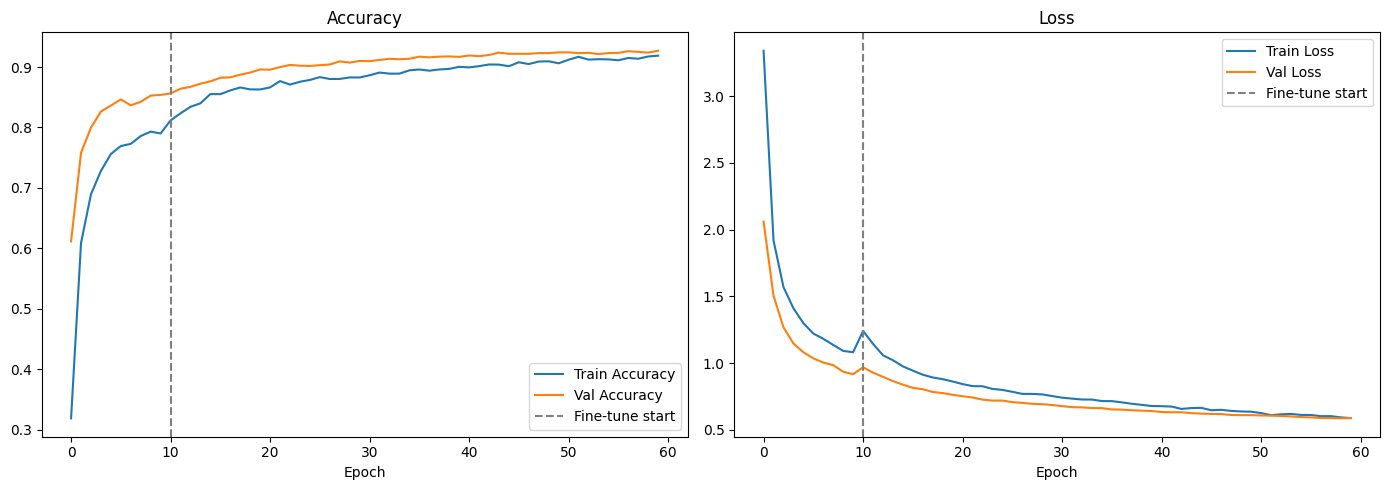

In [14]:
# Combine both phase histories for plotting
acc     = history_phase1.history['accuracy']     + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss    = history_phase1.history['loss']         + history_phase2.history['loss']
val_loss= history_phase1.history['val_loss']     + history_phase2.history['val_loss']

phase1_end = len(history_phase1.history['accuracy'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(acc,     label='Train Accuracy')
ax1.plot(val_acc, label='Val Accuracy')
ax1.axvline(phase1_end, color='gray', linestyle='--', label='Fine-tune start')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(loss,     label='Train Loss')
ax2.plot(val_loss, label='Val Loss')
ax2.axvline(phase1_end, color='gray', linestyle='--', label='Fine-tune start')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig(base_path + 'training_history_v2.png', dpi=150)
plt.show()